In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('telecom_churn.csv')

In [3]:
df.head()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


In [4]:
df.isna().sum().sum()

np.int64(0)

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
masking_value = 0.2
mask = np.random.rand(*df.shape) < masking_value
df_NaN = df.mask(mask)

In [7]:
df_NaN.head()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,NaN,128.0,1.0,NaN,2.7,1.0,265.1,110.0,89.0,NaN,10.0
1,0.0,107.0,1.0,1.0,3.7,1.0,161.6,123.0,82.0,9.78,NaN
2,0.0,137.0,1.0,0.0,0.0,0.0,243.4,NaN,52.0,6.06,NaN
3,0.0,84.0,0.0,0.0,0.0,2.0,299.4,71.0,57.0,NaN,6.6
4,0.0,75.0,NaN,0.0,0.0,3.0,166.7,113.0,NaN,7.42,10.1


In [8]:
k =df_NaN.isna().sum().sum()

In [9]:
n,m = df.shape
t =n*m

In [10]:
print(k/t)

0.1994654010855631


In [11]:
from sklearn.impute import SimpleImputer
nums_col = df.select_dtypes(include=['number']).columns
Num_Imputer = SimpleImputer(strategy='median')
df_NaN[nums_col] = Num_Imputer.fit_transform(df_NaN[nums_col])

In [12]:
df_NaN.isna().sum()

Churn              0
AccountWeeks       0
ContractRenewal    0
DataPlan           0
DataUsage          0
CustServCalls      0
DayMins            0
DayCalls           0
MonthlyCharge      0
OverageFee         0
RoamMins           0
dtype: int64

In [13]:
df.describe()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,0.144914,101.064806,0.903090,0.276628,0.816475,1.562856,179.775098,100.435644,56.305161,10.051488,10.237294
std,0.352067,39.822106,0.295879,0.447398,1.272668,1.315491,54.467389,20.069084,16.426032,2.535712,2.791840
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000
25%,0.000000,74.000000,1.000000,0.000000,0.000000,1.000000,143.700000,87.000000,45.000000,8.330000,8.500000
50%,0.000000,101.000000,1.000000,0.000000,0.000000,1.000000,179.400000,101.000000,53.500000,10.070000,10.300000
75%,0.000000,127.000000,1.000000,1.000000,1.780000,2.000000,216.400000,114.000000,66.200000,11.770000,12.100000
max,1.000000,243.000000,1.000000,1.000000,5.400000,9.000000,350.800000,165.000000,111.300000,18.190000,20.000000


In [14]:
df_NaN.describe()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,0.112211,101.193219,0.921092,0.220522,0.661605,1.448545,179.880198,100.184218,55.554425,10.065047,10.263246
std,0.315674,35.794966,0.269635,0.414661,1.194927,1.206528,48.803488,17.889927,14.793490,2.236268,2.455727
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000
25%,0.000000,81.000000,1.000000,0.000000,0.000000,1.000000,154.000000,91.000000,47.000000,8.760000,9.000000
50%,0.000000,101.000000,1.000000,0.000000,0.000000,1.000000,179.300000,100.000000,53.000000,10.060000,10.300000
75%,0.000000,121.000000,1.000000,0.000000,0.350000,2.000000,207.000000,110.000000,62.000000,11.260000,11.500000
max,1.000000,243.000000,1.000000,1.000000,5.400000,9.000000,350.800000,165.000000,111.300000,18.190000,18.900000


In [15]:
df[nums_col].corr()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
Churn,1.000000,0.016541,-0.259852,-0.102148,-0.087195,0.208750,0.205151,0.018459,0.072313,0.092812,0.068239
AccountWeeks,0.016541,1.000000,-0.024735,0.002918,0.014391,-0.003796,0.006216,0.038470,0.012581,-0.006749,0.009514
ContractRenewal,-0.259852,-0.024735,1.000000,-0.006006,-0.019223,0.024522,-0.049396,-0.003755,-0.047291,-0.019105,-0.045871
DataPlan,-0.102148,0.002918,-0.006006,1.000000,0.945982,-0.017824,-0.001684,-0.011086,0.737490,0.021526,-0.001318
DataUsage,-0.087195,0.014391,-0.019223,0.945982,1.000000,-0.021723,0.003176,-0.007962,0.781660,0.019637,0.162746
CustServCalls,0.208750,-0.003796,0.024522,-0.017824,-0.021723,1.000000,-0.013423,-0.018942,-0.028017,-0.012964,-0.009640
DayMins,0.205151,0.006216,-0.049396,-0.001684,0.003176,-0.013423,1.000000,0.006750,0.567968,0.007038,-0.010155
DayCalls,0.018459,0.038470,-0.003755,-0.011086,-0.007962,-0.018942,0.006750,1.000000,-0.007963,-0.021449,0.021565
MonthlyCharge,0.072313,0.012581,-0.047291,0.737490,0.781660,-0.028017,0.567968,-0.007963,1.000000,0.281766,0.117433
OverageFee,0.092812,-0.006749,-0.019105,0.021526,0.019637,-0.012964,0.007038,-0.021449,0.281766,1.000000,-0.011023


In [16]:
df['Churn'].value_counts()

Churn
0    2850
1     483
Name: count, dtype: int64

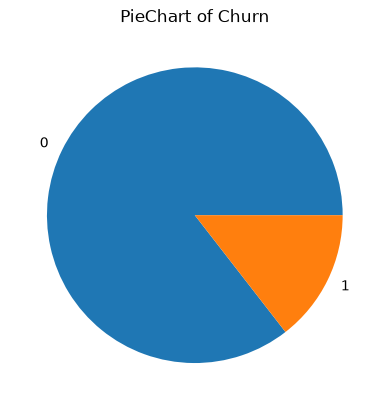

In [17]:
df['Churn'].value_counts().plot(kind='pie')
plt.title("PieChart of Churn")
plt.show()

In [18]:
df.groupby('Churn')['CustServCalls'].mean()

Churn
0    1.449825
1    2.229814
Name: CustServCalls, dtype: float64

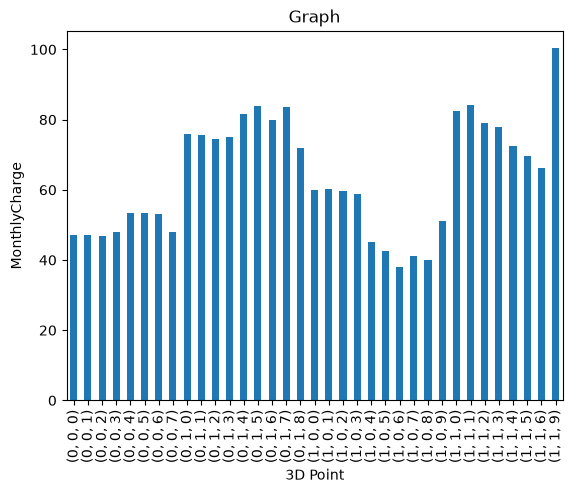

In [19]:
df.groupby(['Churn','DataPlan','CustServCalls'])['MonthlyCharge'].mean().plot(kind='bar')
plt.title('Graph')
plt.ylabel('MonthlyCharge')
plt.xlabel('3D Point')
plt.show()

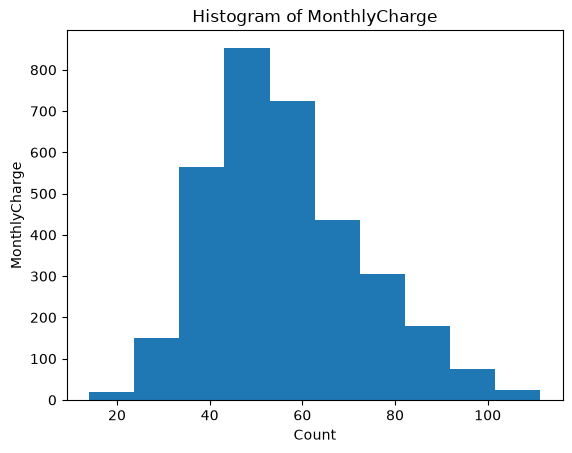

In [20]:
plt.hist(df['MonthlyCharge'])
plt.title('Histogram of MonthlyCharge')
plt.ylabel('MonthlyCharge')
plt.xlabel('Count')
plt.show()

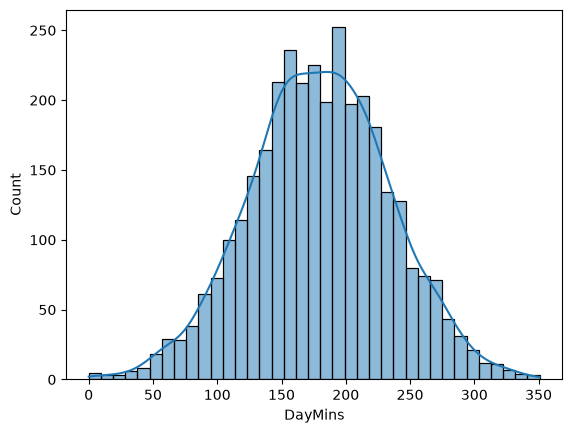

In [21]:
sns.histplot(data=df['DayMins'],kde=True)
plt.show()

In [22]:
df.head(3)

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2


In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [45]:
x = df[['ContractRenewal','DataPlan','DayMins','CustServCalls']]
y = df['Churn']
scalar = StandardScaler()
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [46]:
x_test

,ContractRenewal,DataPlan,DayMins,CustServCalls
1804,0,0,187.3,0
1839,1,0,230.3,1
1980,1,0,177.2,4
1975,1,0,141.2,2
2975,1,0,151.5,0
...,...,...,...,...
1845,0,0,189.1,2
1268,1,0,211.8,0
1695,1,0,202.1,2
3262,1,0,142.2,1


In [47]:
x_train = scalar.fit_transform(x_train)
x_test = scalar.transform(x_test)


In [26]:
import joblib
joblib.dump(scalar,'scalar.pkl')

['scalar.pkl']

In [48]:
from sklearn.metrics import accuracy_score
def pred(predictions):
    k = accuracy_score(y_test,predictions)
    print(f"The accuracy of the model is {k}")

In [49]:
import warnings
warnings.filterwarnings("ignore")

In [50]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

In [51]:
log_model = LogisticRegression()
log_model.fit(x_train,y_train)
y_pred = log_model.predict(x_test)

In [53]:
pred(y_pred)

The accuracy of the model is 0.8665667166416792
